# 03: Benford's Law Analysis

**What this notebook establishes:** the digit-distribution mathematics, the aggregate conformity result, the segmented (country x month) results, and why Mean Absolute Deviation rather than chi-square is the primary conformity criterion at this population size.

**Estimated runtime:** ~1 minute

All logic lives in `src/`; this notebook only calls into it and displays results (plan/00_MASTER_PLAN.md sec 5).

## 1. The mathematics

Benford's Law: the leading digit *d* of many naturally occurring numeric populations occurs with probability `log10(1 + 1/d)`, 1 appears ~30.1% of the time, 9 only ~4.6%. **Mean Absolute Deviation (MAD)** = `mean(|observed_i - expected_i|)` across the 9 digits; Nigrini's thresholds (Close <0.006, Acceptable <0.012, Marginal <0.015, Nonconformity >=0.015) are sample-size independent, unlike chi-square.

In [1]:
import json
import pandas as pd
from pathlib import Path
ROOT = Path('..').resolve()
summary = json.loads((ROOT/'reports/metrics/benford_summary.json').read_text())
pd.DataFrame(summary['aggregate']).T

,n,mad,chi_square,chi2_pvalue,classification
amount_first,990028,0.025094,990026.0,0.0,NONCONFORMING
quantity_first,1027411,0.04899,1027409.0,0.0,NONCONFORMING
amount_second,990028,0.076765,990026.0,0.0,NONCONFORMING


## 2. The excess-power problem

At n ~ 990,000, chi-square rejects conformity for the aggregate population (p ~ 0) even though the MAD (0.025) is only just past the Nonconformity threshold. This is expected: with very large n, chi-square rejects conformity for economically trivial deviations. **MAD is the primary criterion here; chi-square is reported alongside with this explicit caveat**, per `plan/00_MASTER_PLAN.md` Risk R3.

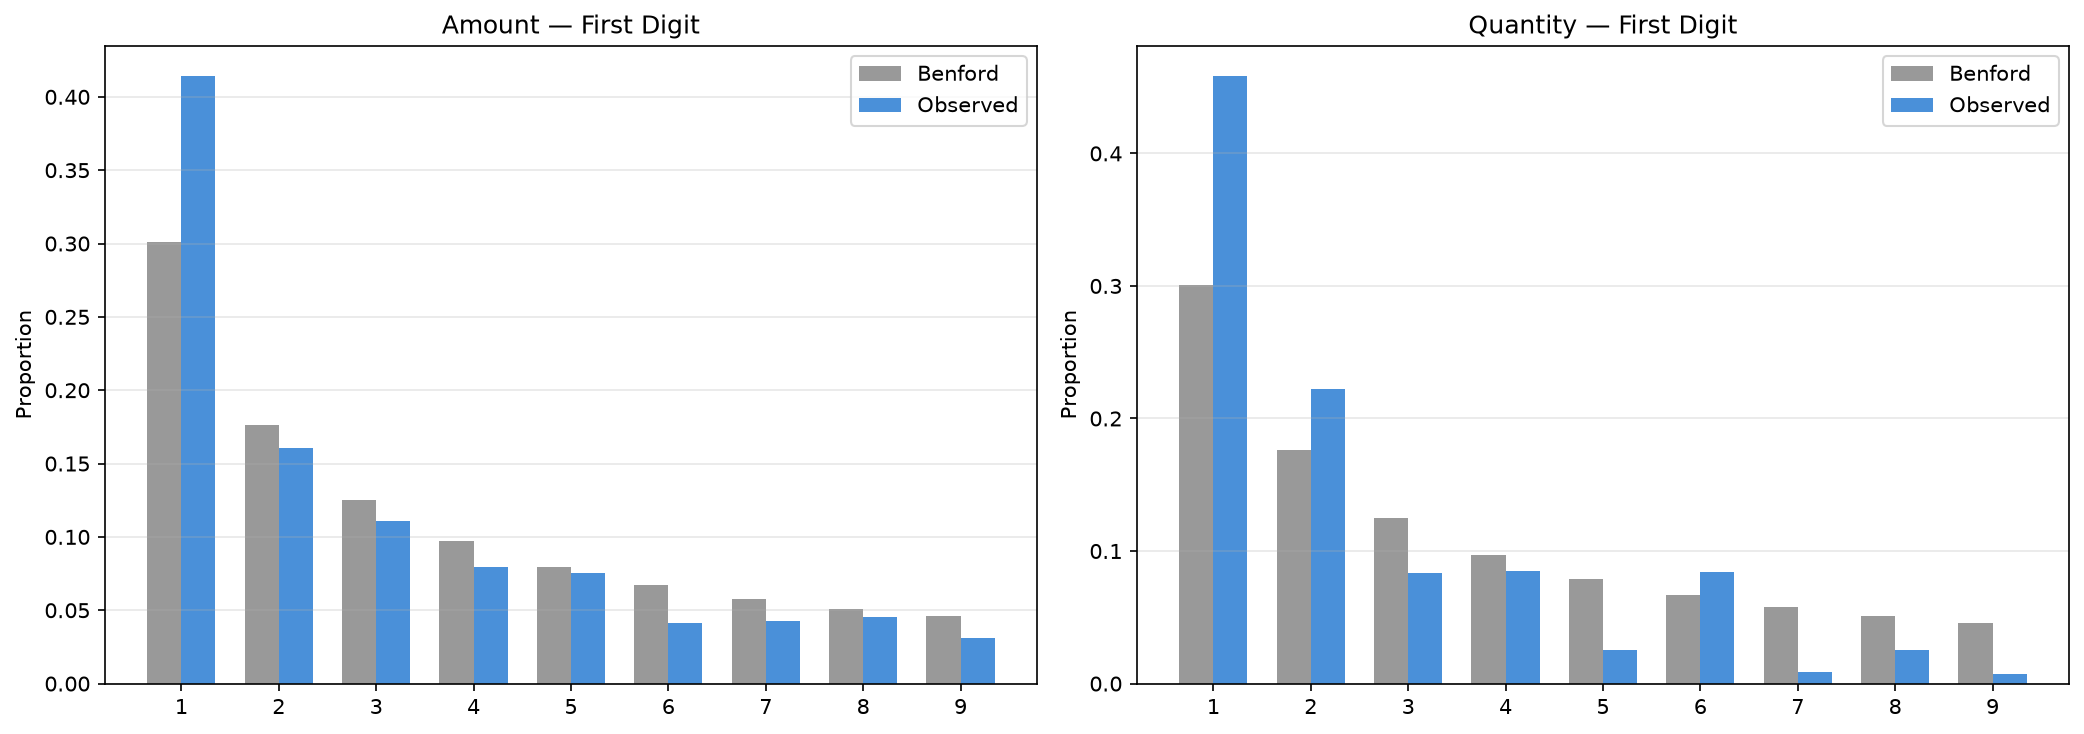

In [2]:
Image_path = ROOT/'reports/figures/benford_first_digit.png'
from IPython.display import Image
Image(filename=str(Image_path))

## 3. Segmented testing

Segmenting by (country, year_month), minimum segment size 1,000 rows, surfaces findings the aggregate test cannot.

In [3]:
print('segments assessed:', summary['segments']['total'])
print('segments nonconforming:', summary['segments']['nonconforming'])
pd.DataFrame(summary['segments']['top_nonconforming'])[['country','year_month','n','mad']].head(10)

segments assessed: 66
segments nonconforming: 66


,country,year_month,n,mad
0,Eire,2011-09,1211,0.066803
1,Eire,2011-11,1097,0.063561
2,Eire,2010-11,1121,0.062552
3,Germany,2011-10,1321,0.061290
4,France,2011-09,1061,0.057306
5,Germany,2011-11,1101,0.052112
6,Eire,2010-10,1467,0.050805
7,France,2011-11,1550,0.045219
8,United Kingdom,2010-09,36023,0.031373
9,United Kingdom,2010-07,29117,0.031302


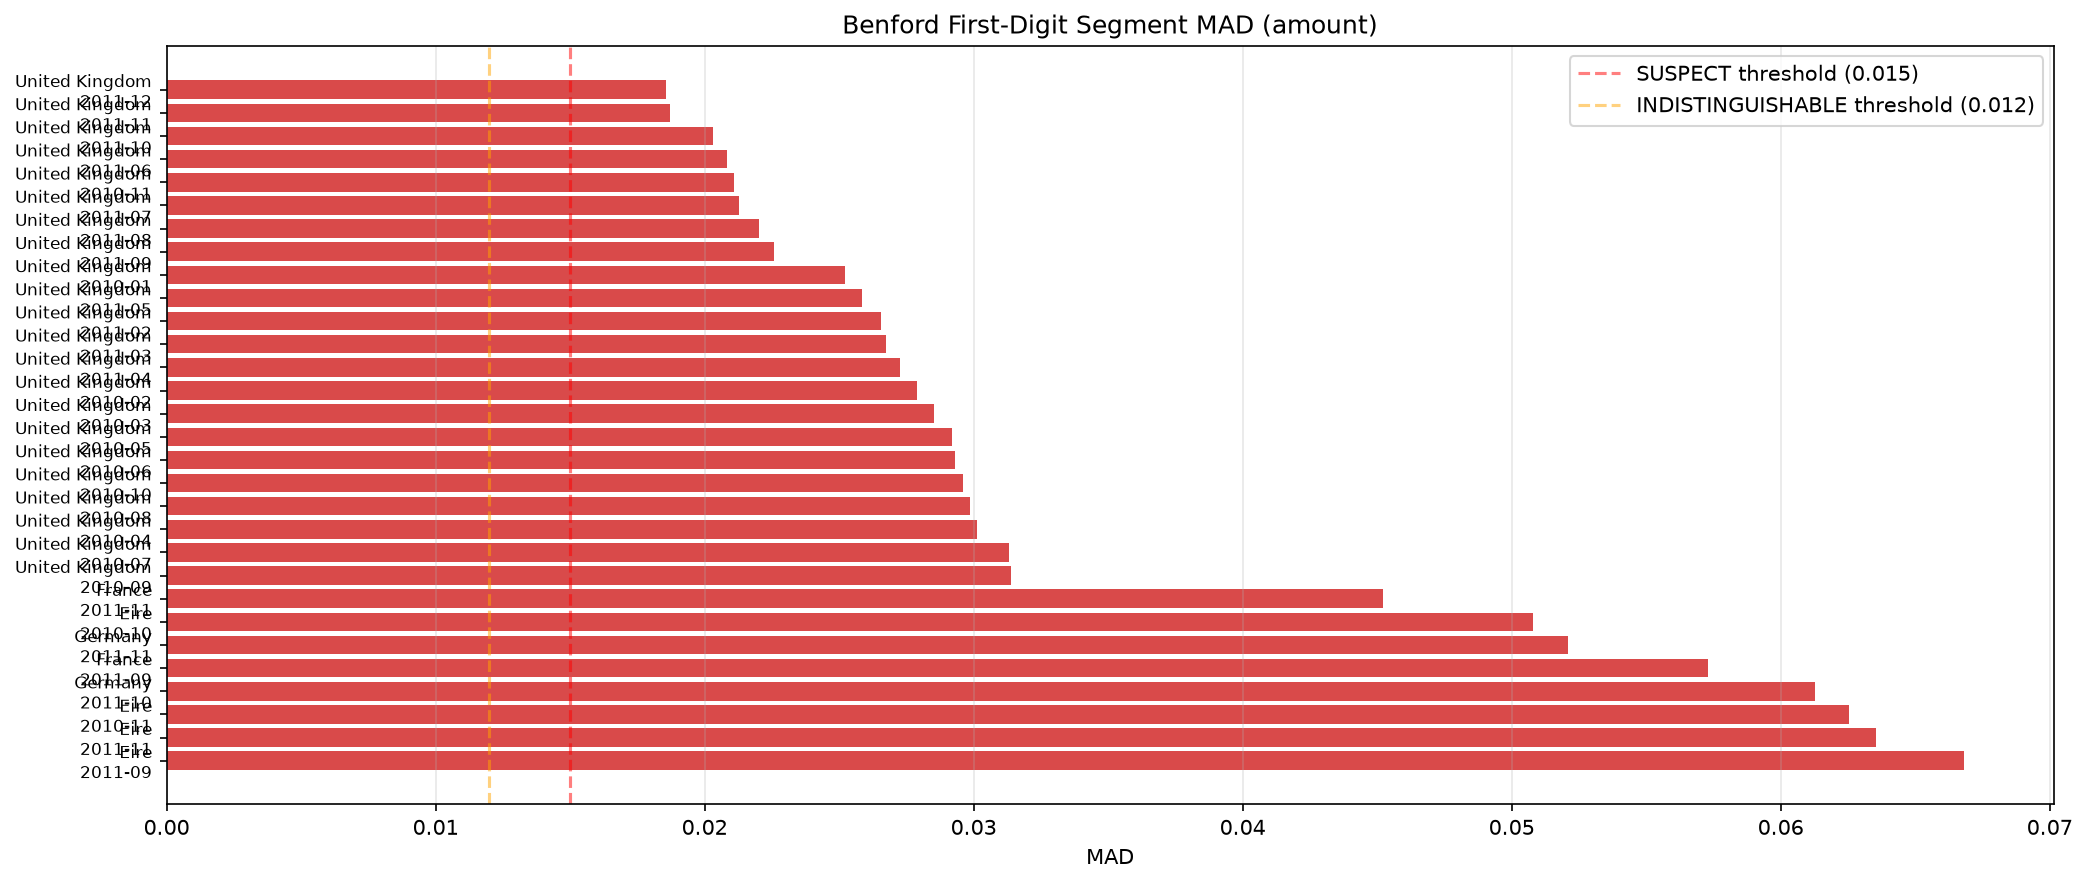

In [4]:
from IPython.display import Image
Image(filename=str(ROOT/'reports/figures/benford_segment_mad.png'))

**Finding:** all 66 segments large enough to test (>=1,000 rows) were classified NONCONFORMING in this run. That is itself a genuine population-level finding worth reporting to an audit manager, but, as Stage 7's validation shows, it means the segment flag is currently too sensitive to serve as a row-level review trigger on its own (see `reports/gate_reports/gate_07.md` and `DECISIONS.md` D-0004).